In [158]:
#Import necessary libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [159]:
df = pd.read_csv("loan_dataset.csv")
df.head()

,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,...,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
0,59,Male,Married,Master's,24240.19,2020.02,Employed,0.074,743,17173.72,...,36,581.88,B5,7,40833.47,24302.07,1,0,1,1
1,72,Female,Married,Bachelor's,20172.98,1681.08,Employed,0.219,531,22663.89,...,60,573.17,F1,5,27968.01,10803.01,1,0,3,1
2,49,Female,Single,High School,26181.80,2181.82,Employed,0.234,779,3631.36,...,60,76.32,B4,2,15502.25,4505.44,0,0,0,1
3,35,Female,Single,High School,11873.84,989.49,Employed,0.264,809,14939.23,...,36,468.07,A5,7,18157.79,5525.63,4,0,5,1
4,63,Other,Single,Other,25326.44,2110.54,Employed,0.260,663,16551.71,...,60,395.50,D5,1,17467.56,3593.91,2,0,2,1


### *Data Inspection*

In [160]:
df.shape #Data shape

(20000, 22)

In [161]:
#Info of the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   20000 non-null  int64  
 1   gender                20000 non-null  object 
 2   marital_status        20000 non-null  object 
 3   education_level       20000 non-null  object 
 4   annual_income         20000 non-null  float64
 5   monthly_income        20000 non-null  float64
 6   employment_status     20000 non-null  object 
 7   debt_to_income_ratio  20000 non-null  float64
 8   credit_score          20000 non-null  int64  
 9   loan_amount           20000 non-null  float64
 10  loan_purpose          20000 non-null  object 
 11  interest_rate         20000 non-null  float64
 12  loan_term             20000 non-null  int64  
 13  installment           20000 non-null  float64
 14  grade_subgrade        20000 non-null  object 
 15  num_of_open_account

In [162]:
df.describe() # Statistical summary

,age,annual_income,monthly_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_term,installment,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,48.027000,43549.637765,3629.136466,0.177019,679.25695,15129.300909,12.400627,43.22280,455.625794,5.011800,48649.824769,24333.394631,1.990150,0.061800,2.489150,0.799900
std,15.829352,28668.579671,2389.048326,0.105059,69.63858,8605.405513,2.442729,11.00838,274.622125,2.244529,32423.378128,22313.845395,1.474945,0.285105,1.631384,0.400085
min,21.000000,6000.000000,500.000000,0.010000,373.00000,500.000000,3.140000,36.00000,9.430000,0.000000,6157.800000,496.350000,0.000000,0.000000,0.000000,0.000000
25%,35.000000,24260.752500,2021.730000,0.096000,632.00000,8852.695000,10.740000,36.00000,253.910000,3.000000,27180.492500,9592.572500,1.000000,0.000000,1.000000,1.000000
50%,48.000000,36585.260000,3048.770000,0.160000,680.00000,14946.170000,12.400000,36.00000,435.595000,5.000000,40241.615000,18334.555000,2.000000,0.000000,2.000000,1.000000
75%,62.000000,54677.917500,4556.495000,0.241000,727.00000,20998.867500,14.002500,60.00000,633.595000,6.000000,60361.257500,31743.327500,3.000000,0.000000,3.000000,1.000000
max,75.000000,400000.000000,33333.330000,0.667000,850.00000,49039.690000,22.510000,60.00000,1685.400000,15.000000,454394.190000,352177.900000,11.000000,2.000000,11.000000,1.000000


In [163]:
#Null values
df.isnull().sum()

age                     0
gender                  0
marital_status          0
education_level         0
annual_income           0
monthly_income          0
employment_status       0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
loan_purpose            0
interest_rate           0
loan_term               0
installment             0
grade_subgrade          0
num_of_open_accounts    0
total_credit_limit      0
current_balance         0
delinquency_history     0
public_records          0
num_of_delinquencies    0
loan_paid_back          0
dtype: int64

In [164]:
#Duplicate values
df.duplicated().sum()

0

### *EDA*

In [165]:
#Target Distribution

df['loan_paid_back'].value_counts()

1    15998
0     4002
Name: loan_paid_back, dtype: int64

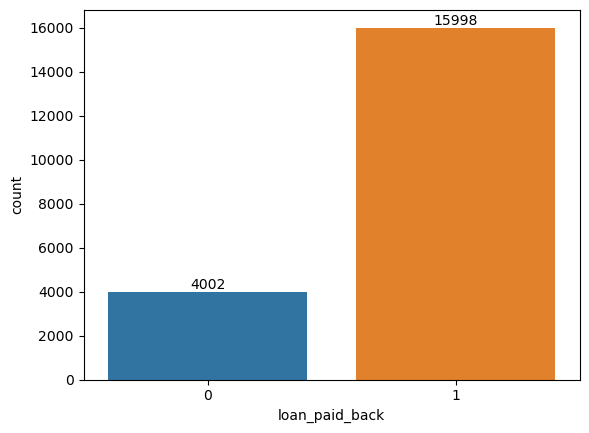

In [166]:
ax = sns.countplot(data= df, x= 'loan_paid_back')
for container in ax.containers:
    ax.bar_label(container)
plt.show()

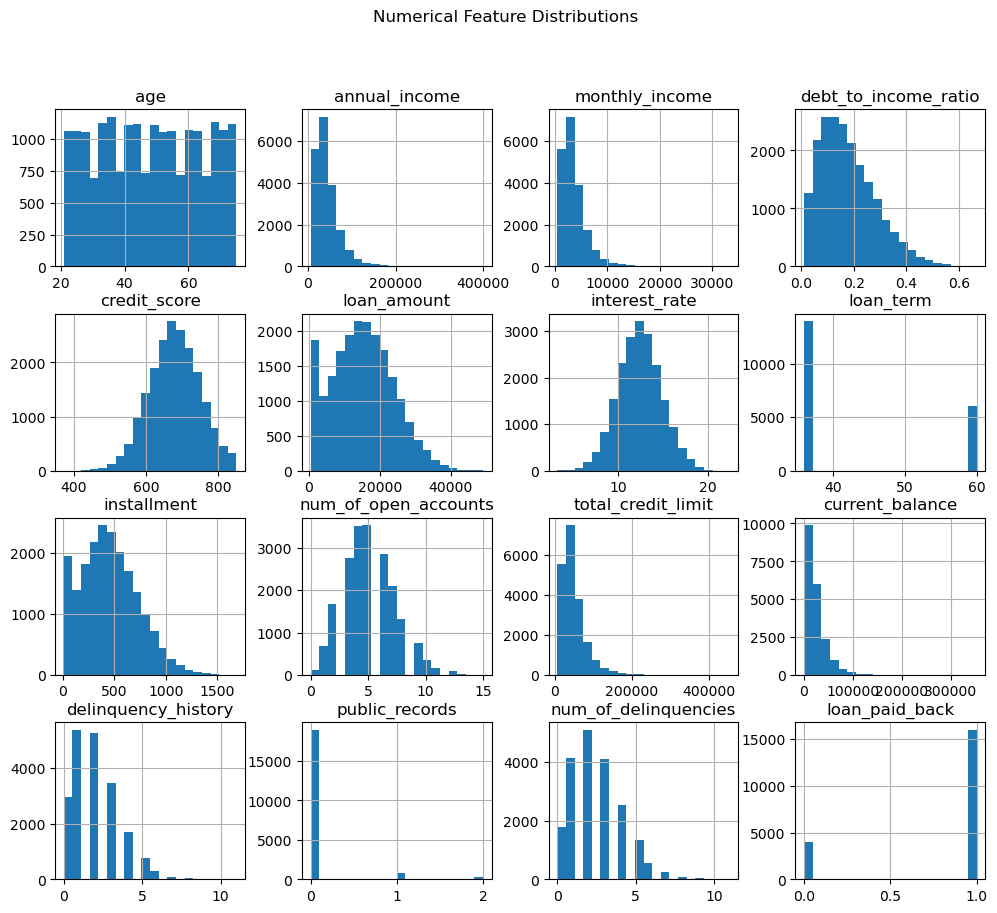

In [167]:
#Numerical column distribution

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[num_cols].hist(figsize=(12, 10), bins=20)
plt.suptitle("Numerical Feature Distributions")
plt.show()

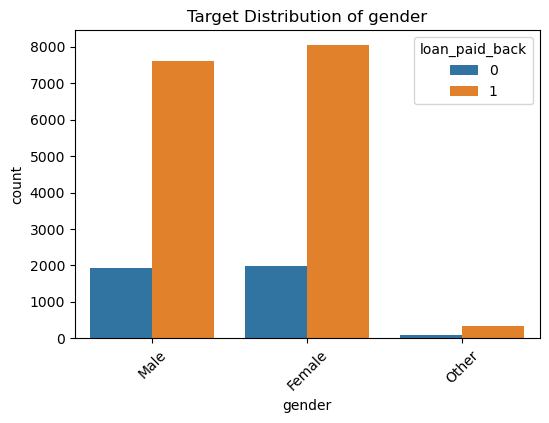

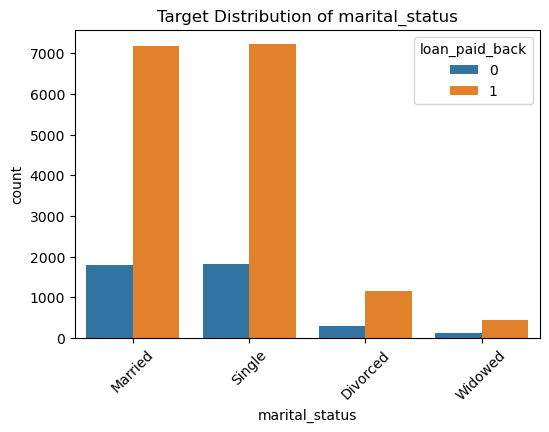

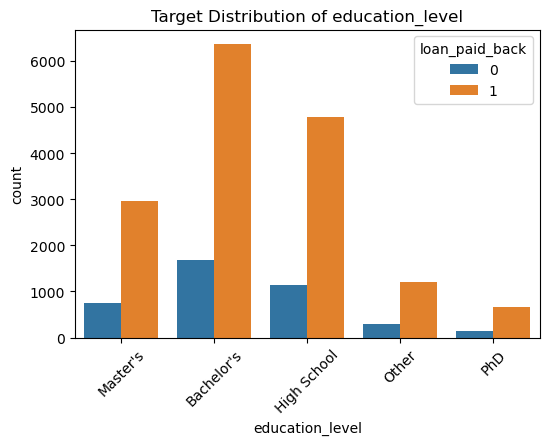

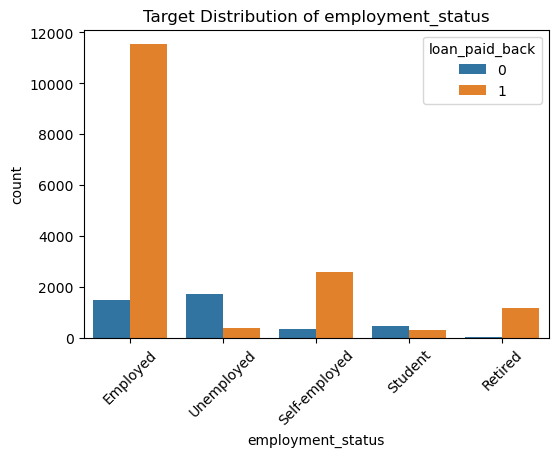

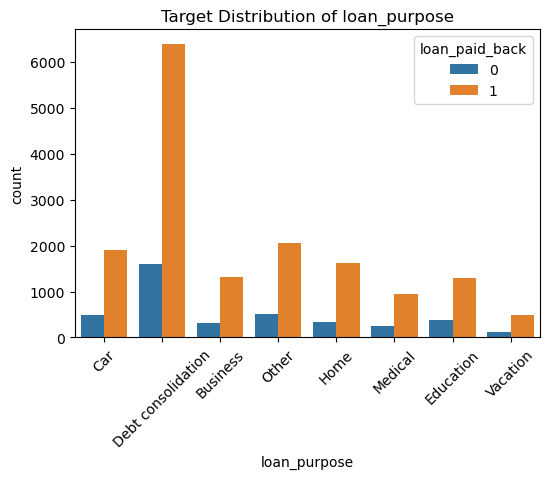

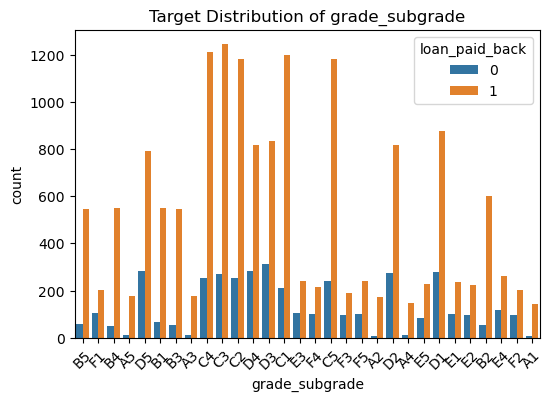

In [168]:
#Categorical columns relation to target
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df, hue='loan_paid_back')
    plt.title(f"Target Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()

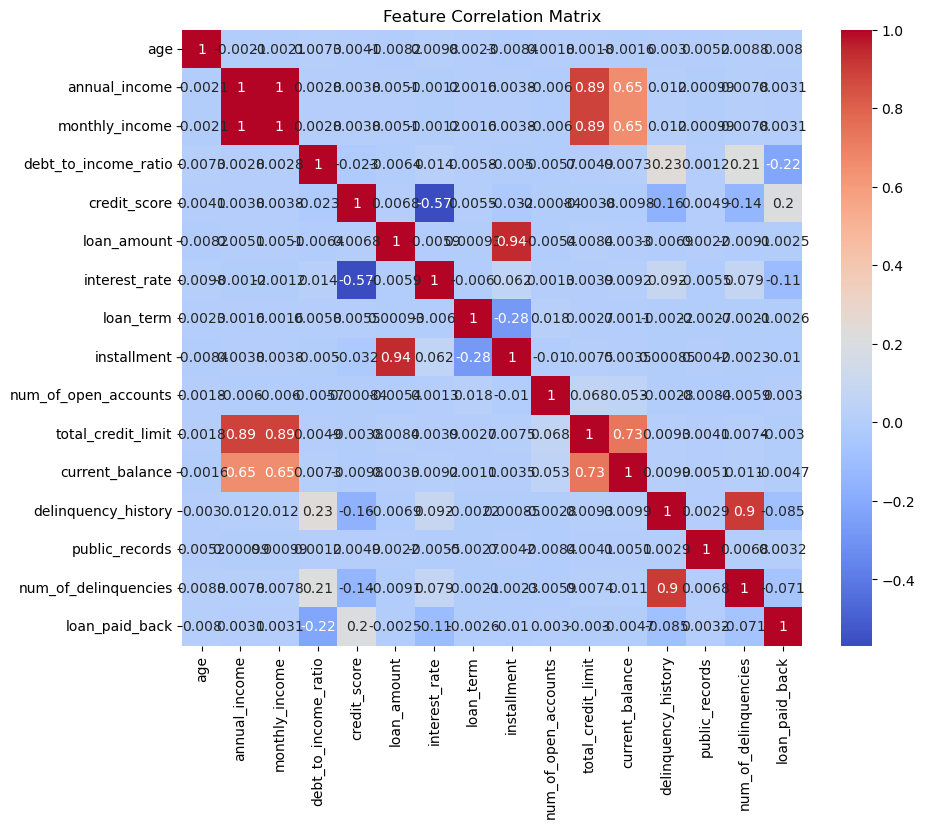

In [169]:
#Correlation heatmap
num_cols = df.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(10, 8))
sns.heatmap(num_cols.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

### *Preprocessing*

In [170]:
# Drop highly correlated features
df.drop(['monthly_income', 'installment'], axis=1, inplace=True)

In [171]:
df.drop(['current_balance'], axis=1, inplace=True)

In [172]:
#Transforming skewed features
skewed_cols = ['annual_income', 'loan_amount', 'total_credit_limit']

for col in skewed_cols:
    df[col] = np.log1p(df[col])

In [173]:
#Checking for multicollinearity

from statsmodels.stats.outliers_influence import variance_inflation_factor

X_temp = df.drop('loan_paid_back', axis=1)
X_temp = X_temp.select_dtypes(include=[np.number])

vif_data = pd.DataFrame()
vif_data["Feature"] = X_temp.columns
vif_data["VIF"] = [variance_inflation_factor(X_temp.values, i) for i in range(len(X_temp.columns))]

print(vif_data)

                 Feature          VIF
0                    age    10.113598
1          annual_income  1437.200597
2   debt_to_income_ratio     4.046075
3           credit_score    95.996174
4            loan_amount    76.932534
5          interest_rate    30.264954
6              loan_term    16.088842
7   num_of_open_accounts     6.346589
8     total_credit_limit  1531.723870
9    delinquency_history    15.585677
10        public_records     1.047284
11  num_of_delinquencies    18.109635


In [174]:
keep_cols = [
    'age',
    'annual_income',
    'debt_to_income_ratio',
    'credit_score',
    'interest_rate',
    'loan_term',
    'num_of_open_accounts',
    'delinquency_history',
    'public_records',
    'num_of_delinquencies'
]

In [175]:
#Dropping columns with high multicollinearity
df.drop([
    'total_credit_limit',   # strongly tied to income
    'loan_amount',          # tied to income + credit
], axis=1, inplace=True)

### *Feature Selection*

In [176]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [177]:
#Feature Selection
X = df.drop('loan_paid_back', axis=1)
y = df["loan_paid_back"]

In [178]:
# Separate column types
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Numerical pipeline: scaling
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

# Categorical pipeline: one-hot encoding
categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine both pipelines
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

In [179]:
# TRAIN-TEST SPLIT
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # maintains class balance
)

### *Modeling*

In [180]:
from sklearn.linear_model import LogisticRegression

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from imblearn.combine import SMOTETomek

pipeline = ImbPipeline(steps=[
    ('preprocessing', preprocessor),
    ('smote_tomek', SMOTETomek(random_state=42)),
    ('model', LogisticRegression(max_iter=1000))
])
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'annual_income',
                                                   'debt_to_income_ratio',
                                                   'credit_score',
                                                   'interest_rate', 'loan_term',
                                                   'num_of_open_accounts',
                                                   'delinquency_history',
                                                   'public_records',
                                                   'num_of_delinquencies']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'marital_status',
                                                   'education_level',
                                                   'employment_status',
                                                   'loan_purpose',
                                                   'grade_subgrade'])])),
                ('smote_tomek', SMOTETomek(random_state=42)),
                ('model', LogisticRegression(max_iter=1000))])

In [181]:
#Hyperparameter tuning

random_search = RandomizedSearchCV(
    pipeline,
    param_distributions={
        "model__C": np.logspace(-2, 2, 10)
    },
    n_iter=5,     # only try 5 configs
    cv=3,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('scaler',
                                                                                                StandardScaler())]),
                                                                               ['age',
                                                                                'annual_income',
                                                                                'debt_to_income_ratio',
                                                                                'credit_score',
                                                                                'interest_rate',
                                                                                'loan_term',
                                                                                'num_of_open_accounts',
                                                                                'delinquency_history',
                                                                                'public_records',
                                                                                'num_of_delinquencies']),
                                                                              ('cat',
                                                                               Pipeline(steps=...
                                                                                'grade_subgrade'])])),
                                             ('smote_tomek',
                                              SMOTETomek(random_state=42)),
                                             ('model',
                                              LogisticRegression(max_iter=1000))]),
                   n_iter=5, n_jobs=-1,
                   param_distributions={'model__C': array([1.00000000e-02, 2.78255940e-02, 7.74263683e-02, 2.15443469e-01,
       5.99484250e-01, 1.66810054e+00, 4.64158883e+00, 1.29154967e+01,
       3.59381366e+01, 1.00000000e+02])},
                   random_state=42, scoring='roc_auc')

In [183]:
# EVALUATION

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)

best_model = random_search.best_estimator_

threshold = 0.35  # try 0.3–0.45 range

y_pred_new = (y_prob >= threshold).astype(int)
y_prob = best_model.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred_new))
print(classification_report(y_test, y_pred_new))
print("\n\nAccuracy:", accuracy_score(y_test, y_pred_new))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob))

[[ 518  282]
 [ 255 2945]]
              precision    recall  f1-score   support

           0       0.67      0.65      0.66       800
           1       0.91      0.92      0.92      3200

    accuracy                           0.87      4000
   macro avg       0.79      0.78      0.79      4000
weighted avg       0.86      0.87      0.86      4000



Accuracy: 0.86575

ROC-AUC Score: 0.88542890625


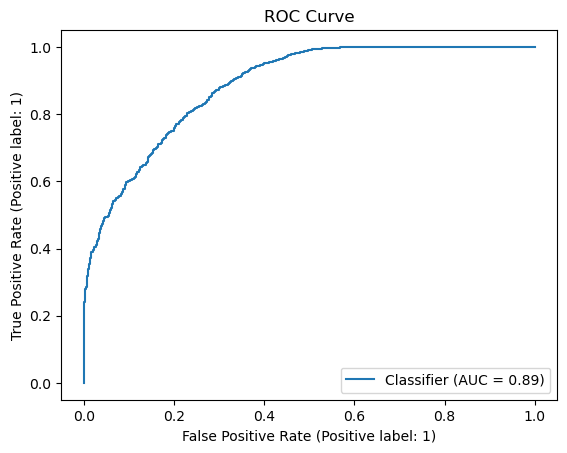

In [184]:
#ROC Curve
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("ROC Curve")
plt.show()

In [ ]:
# FEATURE IMPORTANCE EXTRACTION (MODEL INTERPRETATION)

# Extract transformed feature names from the preprocessing step
# This includes scaled numerical features and encoded categorical features
feature_names = best_model.named_steps['preprocessing'].get_feature_names_out()
coefficients = best_model.named_steps['model'].coef_[0]

# Sort features based on coefficient values in descending order
# Higher positive values → increase probability of class 1 (loan paid back)
# More negative values → increase probability of class 0 (default)
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
}).sort_values(by="Coefficient", ascending=False)

print(importance_df.head(10))

                                 Feature  Coefficient
23        cat__employment_status_Retired     4.506250
36                cat__grade_subgrade_A2     1.261813
3                      num__credit_score     1.188559
64                cat__grade_subgrade_F5     1.142731
24  cat__employment_status_Self-employed     0.985249
35                cat__grade_subgrade_A1     0.839311
22       cat__employment_status_Employed     0.756703
62                cat__grade_subgrade_F3     0.526667
37                cat__grade_subgrade_A3     0.516215
61                cat__grade_subgrade_F2     0.472585
